# **Importing necessary libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
# from scipy.stats.contingency import chi2_contingency
import seaborn as sns
from datetime import datetime, date, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score,recall_score,confusion_matrix
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import *
# from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score,roc_curve
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip uninstall scikit-learn imbalanced-learn -y

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
Found existing installation: imbalanced-learn 0.14.1
Uninstalling imbalanced-learn-0.14.1:
  Successfully uninstalled imbalanced-learn-0.14.1
Note: you may need to restart the kernel to use updated packages.


You can safely remove it manually.


In [3]:
!pip install scikit-learn --upgrade
!pip install imbalanced-learn --upgrade

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)


In [68]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 11.4 MB/s eta 0:00:09
   - -------------------------------------- 3.9/101.7 MB 13.1 MB/s eta 0:00:08
   -- ------------------------------------- 6.0/101.7 MB 11.8 MB/s eta 0:00:09
   --- ------------------------------------ 8.7/101.7 MB 12.0 MB/s eta 0:00:08
   ---- ----------------------------------- 11.8/101.7 MB 12.8 MB/s eta 0:00:08
   ----- ---------------------------------- 14.7/101.7 MB 13.1 MB/s eta 0:00:07
   ------- -------------------------------- 17.8/101.7 MB 13.4 MB/s eta 0:00:07
   ------- -------------------------------- 19.4/101.7 MB 13.2 MB/s eta 0:00:07
   -------- ------------------------------- 20.7/101.7 MB 12.4 MB/s eta 0:00:07
   -------- ------------------------------- 20.7/101.7 MB 12.4 MB/s eta 0:00:07
   -------- ------------------------------- 21.5/101.7 MB 10.7 MB/s eta 0:00:08
   -------- ------------------------------- 22.3/101.

## Load datasets after Data Consolidation for Bus, Subway, and Streetcar Datasets for the years 2023, 2024, and 2025 -->  **TTC_Bus_combined.csv, TTC_Streetcar_combined.csv and TTC_Subway_combined**

In [4]:
ttc_subway = pd.read_csv("TTC_Subway_combined.csv")
ttc_bus = pd.read_csv("TTC_Bus_combined.csv")
ttc_streetcar= pd.read_csv("TTC_Streetcar_combined.csv")

In [5]:
# ----------------------------
# Filter valid rows
# ----------------------------

# Keep only rows where:
# - Line is not missing
# - Bound (direction) is not missing
# This ensures we work with complete and usable data
ttc_subway_filtered = ttc_subway[
    (ttc_subway["Line"].notna()) &
    (ttc_subway["Bound"].notna())
].copy()


# ----------------------------
# Standardize subway line names
# ----------------------------

# Replace inconsistent naming:
# - "YUS" → "YU" (same Line 1: Yonge-University)
# - "YUS/BD" → "BD" (represents delays affecting both lines,
#   simplified to BD for consistency in analysis)
ttc_subway_filtered["Line"] = ttc_subway_filtered["Line"].replace({
    "YUS": "YU",
    "YUS/BD": "BD"   # simplifying combined label
})


# ----------------------------
# Preview cleaned data
# ----------------------------

# Display first few rows to verify changes
ttc_subway_filtered.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,Subway
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,Subway
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,Subway
7,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,Subway
8,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,Subway


In [6]:
ttc_subway_filtered.shape
# (74395, 11)

(47179, 11)

In [7]:
# ----------------------------
# Filter valid rows
# ----------------------------

# Keep only rows where:
# - Line is not missing
# - Bound (direction) is not missing

ttc_bus_filtered = ttc_bus[
    (ttc_bus["Line"].notna()) &
    (ttc_bus["Bound"].notna())
].copy()


# ----------------------------
# Extract numeric route number
# ----------------------------

# Extract only the numeric part from the Line column
# Example: "52 LAWRENCE WEST" → 52
ttc_bus_filtered["Line"] = ttc_bus_filtered["Line"].str.extract(r'(\d+)')


# ----------------------------
# Remove invalid extracted values
# ----------------------------

# Drop rows where no numeric route was found (NaN after extraction)
ttc_bus_filtered = ttc_bus_filtered.dropna(subset=["Line"])


# ----------------------------
# Convert to integer
# ----------------------------

# Convert Line column from string to integer for analysis
ttc_bus_filtered["Line"] = ttc_bus_filtered["Line"].astype(int)


# ----------------------------
# Keep only valid TTC routes
# ----------------------------

# Define valid TTC bus route ranges:
# - 1–199 → regular routes
# - 300–399 → night routes
# - 900–999 → express routes
valid_routes = list(range(1, 200)) + list(range(300, 400)) + list(range(900, 1000))

# Filter dataset to keep only valid route numbers
# Removes noise such as vehicle IDs or incorrect values
ttc_bus_filtered = ttc_bus_filtered[
    ttc_bus_filtered["Line"].isin(valid_routes)
]


# ----------------------------
# Preview cleaned data
# ----------------------------

# Display first few rows to verify cleaning steps
ttc_bus_filtered.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type
3,2023-01-01,52,04:25,Sunday,LAWRENCE AND YONGE,Emergency Services,30,60,E,3520,Bus
5,2023-01-01,300,06:04,Sunday,DANFOTH AND LOGAN,Mechanical,138,148,E,3339,Bus
6,2023-01-01,320,06:07,Sunday,STEELES LOOP,Emergency Services,6,12,E,3462,Bus
9,2023-01-01,73,07:55,Sunday,ROYAL YORK STATION,Mechanical,10,20,E,3350,Bus
10,2023-01-01,102,07:57,Sunday,MORNINGSIDE AND PASSMO,Mechanical,20,40,N,3429,Bus


In [8]:
ttc_bus_filtered.shape

(81636, 11)

In [9]:
# ----------------------------
# Filter valid rows
# ----------------------------

# Keep only rows where:
# - Line is not missing
# - Bound (direction) is not missing

ttc_streetcar_filtered = ttc_streetcar[

    (ttc_streetcar["Line"].notna()) &
    (ttc_streetcar["Bound"].notna())
].copy()


# ----------------------------
# Extract numeric route number
# ----------------------------

# Extract numeric part from the Line column
# Example: "504 KING" → 504
ttc_streetcar_filtered["Line"] = ttc_streetcar_filtered["Line"].str.extract(r'(\d+)')


# ----------------------------
# Remove invalid extracted values
# ----------------------------

# Drop rows where no numeric route was found (NaN after extraction)
ttc_streetcar_filtered = ttc_streetcar_filtered.dropna(subset=["Line"])


# ----------------------------
# Convert to integer
# ----------------------------

# Convert Line column to integer for analysis
ttc_streetcar_filtered["Line"] = ttc_streetcar_filtered["Line"].astype(int)


# ----------------------------
# Keep only valid TTC streetcar routes
# ----------------------------

# Define valid TTC streetcar routes
valid_routes = [501, 503, 504, 505, 506, 509, 510, 511, 512]

# Filter dataset to retain only valid streetcar routes
# Removes any incorrect values or noise
ttc_streetcar_filtered = ttc_streetcar_filtered[
    ttc_streetcar_filtered["Line"].isin(valid_routes)
]


# ----------------------------
# Preview cleaned data
# ----------------------------

# Display first few rows to verify cleaning steps
ttc_streetcar_filtered.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type
0,2023-01-01,505,03:53,Sunday,LANSDOWNE AND DUNDAS,Emergency Services,0,0,N,4460,Streetcar
1,2023-01-01,506,09:58,Sunday,PARLIAMENT AND ST DAVI,Emergency Services,10,19,S,4519,Streetcar
3,2023-01-01,501,14:21,Sunday,QUEEN AND PETER,Emergency Services,8,15,W,4582,Streetcar
4,2023-01-01,510,15:19,Sunday,HARBOUR FRONT TUNNEL,Emergency Services,0,0,W,4534,Streetcar
5,2023-01-01,506,15:38,Sunday,DUNDAS AND BAY,Mechanical,9,18,E,4522,Streetcar


In [10]:
ttc_streetcar_filtered.shape

(8850, 11)

In [11]:
# ----------------------------
# Save cleaned datasets to CSV files
# ----------------------------

# Save the cleaned subway dataset to a CSV file
# index=False ensures that the row index is not included in the output file
ttc_subway_filtered.to_csv("ttc_subway_filtered.csv", index=False)

# Save the cleaned bus dataset to a CSV file
ttc_bus_filtered.to_csv("ttc_bus_filtered.csv", index=False)

# Save the cleaned streetcar dataset to a CSV file
ttc_streetcar_filtered.to_csv("ttc_streetcar_filtered.csv", index=False)

In [12]:
# ----------------------------
# Inspect column names of all datasets
# ----------------------------

# Print column names of the cleaned subway dataset
# Ensures all required fields are present and correctly named
print(ttc_subway_filtered.columns)

# Print column names of the cleaned bus dataset
# Useful for comparing structure with other datasets
print(ttc_bus_filtered.columns)

# Print column names of the cleaned streetcar dataset
# Helps verify consistency before merging datasets
print(ttc_streetcar_filtered.columns)

Index(['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle', 'Transport_Type'],
      dtype='object')
Index(['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle', 'Transport_Type'],
      dtype='object')
Index(['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle', 'Transport_Type'],
      dtype='object')


In [13]:
# ----------------------------
# Check dataset dimensions
# ----------------------------

# Print shape of the cleaned subway dataset
# Shows (number of rows, number of columns)
print(ttc_subway_filtered.shape)

# Print shape of the cleaned bus dataset
# Helps understand dataset size after cleaning
print(ttc_bus_filtered.shape)

# Display shape of the cleaned streetcar dataset
# (In notebooks, this will display automatically)
ttc_streetcar_filtered.shape

(47179, 11)
(81636, 11)


(8850, 11)

In [14]:
# ----------------------------
# Combine all transport datasets
# ----------------------------

# Concatenate (merge vertically) the cleaned subway, bus, and streetcar datasets
# into a single unified dataset for analysis
ttc_all = pd.concat(
    [
        ttc_subway_filtered,      # cleaned subway data
        ttc_bus_filtered,         # cleaned bus data
        ttc_streetcar_filtered   # cleaned streetcar data
    ],
    ignore_index=True            # reset row numbering during concatenation
).reset_index(drop=True)        # ensure a clean, continuous index after merging

In [15]:
ttc_all

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,Subway
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,Subway
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,Subway
3,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,Subway
4,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,Subway
...,...,...,...,...,...,...,...,...,...,...,...
137660,2025-12-28,503,15:26,Sunday,YORK AND KING,Emergency Services,10,20,N,8351,Streetcar
137661,2025-12-31,503,7:29,Wednesday,GARDINER EXPRESSWAY AN,Emergency Services,9,18,E,8162,Streetcar
137662,2025-12-31,503,14:26,Wednesday,QUEEN AND BOULTON,Mechanical,6,12,W,8636,Streetcar
137663,2025-12-31,503,15:37,Wednesday,QUEEN AND COXWELL,Mechanical,6,12,W,3345,Streetcar


In [16]:
# ----------------------------
# Import required libraries
# ----------------------------

import requests          # for making API requests
import pandas as pd     # for data manipulation


# ----------------------------
# Fetch weather data from Open-Meteo API
# ----------------------------

# Define API endpoint for historical weather data
url = "https://archive-api.open-meteo.com/v1/archive"

# Define parameters for the API request
params = {
    "latitude": 43.6777,          # Toronto Pearson Airport latitude
    "longitude": -79.6248,        # Toronto Pearson Airport longitude
    "start_date": "2023-01-01",   # start date of data
    "end_date": "2025-12-31",     # end date of data
    "hourly": "temperature_2m,precipitation,windspeed_10m,weathercode",  # variables to retrieve
    "timezone": "America/Toronto" # ensure local time alignment
}

# Send GET request to API and store response
response = requests.get(url, params=params)

# Convert JSON response into Python dictionary
data = response.json()


# ----------------------------
# Convert API data to DataFrame
# ----------------------------

# Create DataFrame from hourly weather data
df_weather = pd.DataFrame(data["hourly"])

# Convert time column to datetime format for analysis
df_weather["time"] = pd.to_datetime(df_weather["time"])


# ----------------------------
# Weather Code Mapping (WMO standard)
# ----------------------------

# Map numeric weather codes to descriptive categories
# Based on World Meteorological Organization (WMO) standards
weather_code_map = {
    0: "Clear sky",
    1: "Mainly clear",
    2: "Partly cloudy",
    3: "Overcast",
    45: "Fog",
    48: "Rime fog",
    51: "Light drizzle",
    53: "Moderate drizzle",
    55: "Dense drizzle",
    61: "Light rain",
    63: "Moderate rain",
    65: "Heavy rain",
    66: "Light freezing rain",
    67: "Heavy freezing rain",
    71: "Light snow",
    73: "Moderate snow",
    75: "Heavy snow",
    77: "Snow grains",
    80: "Light rain showers",
    81: "Moderate rain showers",
    82: "Violent rain showers",
    85: "Light snow showers",
    86: "Heavy snow showers",
    95: "Thunderstorm",
    96: "Thunderstorm with hail",
    99: "Severe thunderstorm with hail"
}

# Add a new column with descriptive weather labels
df_weather["weather_desc"] = df_weather["weathercode"].map(weather_code_map)


# ----------------------------
# Preview dataset
# ----------------------------

# Display first few rows of the weather dataset
df_weather.head()

,time,temperature_2m,precipitation,windspeed_10m,weathercode,weather_desc
0,2023-01-01 00:00:00,2.5,0.0,11.8,3,Overcast
1,2023-01-01 01:00:00,2.5,0.0,10.3,3,Overcast
2,2023-01-01 02:00:00,2.3,0.0,7.6,3,Overcast
3,2023-01-01 03:00:00,1.9,0.0,8.7,3,Overcast
4,2023-01-01 04:00:00,2.0,0.0,9.4,3,Overcast


In [17]:
# ----------------------------
# Check unique weather categories
# ----------------------------

# Display all unique values in the 'weather_desc' column
# This helps identify different weather conditions present in the dataset

df_weather.weather_desc.unique()

array(['Overcast', 'Light drizzle', 'Moderate snow', 'Light snow',
       'Partly cloudy', 'Moderate drizzle', 'Dense drizzle',
       'Moderate rain', 'Mainly clear', 'Clear sky', 'Heavy snow',
       'Light rain', 'Heavy rain'], dtype=object)

In [18]:
# ----------------------------
# Create weather-based features
# ----------------------------

# Create a binary variable for rain conditions
# Includes both "rain" and "drizzle" categories
# case=False → ignores uppercase/lowercase differences
# na=False → treats missing values as False
# .astype(int) → converts True/False to 1/0
df_weather["is_rain"] = df_weather["weather_desc"].str.contains(
    "rain|drizzle", case=False, na=False
).astype(int)


# Create a binary variable for snow conditions
# Identifies all weather descriptions containing "snow"
df_weather["is_snow"] = df_weather["weather_desc"].str.contains(
    "snow", case=False, na=False
).astype(int)


# Create a binary variable for clear conditions
# A row is considered "clear" if:
# - it is NOT rain
# - it is NOT snow
# This captures clear, cloudy, and other non-precipitation conditions
df_weather["is_clear"] = (
    (df_weather["is_rain"] == 0) &
    (df_weather["is_snow"] == 0)
).astype(int)


# ----------------------------
# Preview updated dataset
# ----------------------------

# Display first few rows to verify new features
df_weather.head()

,time,temperature_2m,precipitation,windspeed_10m,weathercode,weather_desc,is_rain,is_snow,is_clear
0,2023-01-01 00:00:00,2.5,0.0,11.8,3,Overcast,0,0,1
1,2023-01-01 01:00:00,2.5,0.0,10.3,3,Overcast,0,0,1
2,2023-01-01 02:00:00,2.3,0.0,7.6,3,Overcast,0,0,1
3,2023-01-01 03:00:00,1.9,0.0,8.7,3,Overcast,0,0,1
4,2023-01-01 04:00:00,2.0,0.0,9.4,3,Overcast,0,0,1


In [19]:
# ----------------------------
# Save cleaned weather dataset
# ----------------------------

# Export the processed weather dataset to a CSV file
# The file will contain hourly weather data along with engineered features (e.g., rain, snow, clear)
# index=False ensures that the DataFrame index is not included in the output file
df_weather.to_csv("toronto_hourly_weather_2025_clean.csv", index=False)

In [20]:
# ----------------------------
# Create a unified datetime column
# ----------------------------

# Combine the separate Date and Time columns into a single datetime column
# - Convert Date to string to ensure proper concatenation
# - Join Date and Time with a space (e.g., "2025-01-01 14:30")
# - Convert the combined string into a datetime object
# - format='mixed' allows pandas to handle different time formats if present
ttc_all["datetime"] = pd.to_datetime(
    ttc_all["Date"].astype(str) + " " + ttc_all["Time"],
    format='mixed'
)


# ----------------------------
# Preview updated dataset
# ----------------------------

# Display first few rows to verify the new datetime column
ttc_all.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type,datetime
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,Subway,2023-01-01 02:22:00
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,Subway,2023-01-01 02:30:00
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,Subway,2023-01-01 02:33:00
3,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,Subway,2023-01-01 08:02:00
4,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,Subway,2023-01-01 08:11:00


In [21]:
# ----------------------------
# Align datetime to hourly level
# ----------------------------

# Round (floor) the datetime to the nearest hour
# Example: 2025-01-01 14:37 → 2025-01-01 14:00
# This is useful for matching with hourly weather data
ttc_all["hour"] = ttc_all["datetime"].dt.floor("H")


# ----------------------------
# Preview updated dataset
# ----------------------------

# Display first few rows to verify the new 'hour' column
ttc_all.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Transport_Type,datetime,hour
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,Subway,2023-01-01 02:22:00,2023-01-01 02:00:00
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,Subway,2023-01-01 02:30:00,2023-01-01 02:00:00
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,Subway,2023-01-01 02:33:00,2023-01-01 02:00:00
3,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,Subway,2023-01-01 08:02:00,2023-01-01 08:00:00
4,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,Subway,2023-01-01 08:11:00,2023-01-01 08:00:00


In [22]:
# ----------------------------
# Rename column for merging
# ----------------------------

# Rename the 'time' column to 'hour'
# This ensures consistency with the TTC dataset,
# where the datetime column was rounded to hourly values (named "hour")
# inplace=True updates the DataFrame directly without creating a copy
df_weather.rename(columns={"time": "hour"}, inplace=True)

In [23]:
# ----------------------------
# Merge TTC data with weather data
# ----------------------------

# Perform a left join between TTC delay data (ttc_all) and weather data (df_weather)
# on the 'hour' column (common key)
# - 'on="hour"' ensures matching based on hourly timestamps
# - 'how="left"' keeps all TTC records and adds weather data where available
ttc_weather = pd.merge(
    ttc_all,
    df_weather,
    on="hour",
    how="left"
)


# ----------------------------
# Preview merged dataset
# ----------------------------

# Display first few rows to verify successful merge
ttc_weather.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,...,datetime,hour,temperature_2m,precipitation,windspeed_10m,weathercode,weather_desc,is_rain,is_snow,is_clear
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,...,2023-01-01 02:22:00,2023-01-01 02:00:00,2.3,0.0,7.6,3,Overcast,0,0,1
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,...,2023-01-01 02:30:00,2023-01-01 02:00:00,2.3,0.0,7.6,3,Overcast,0,0,1
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,...,2023-01-01 02:33:00,2023-01-01 02:00:00,2.3,0.0,7.6,3,Overcast,0,0,1
3,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,...,2023-01-01 08:02:00,2023-01-01 08:00:00,2.4,0.0,10.5,3,Overcast,0,0,1
4,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,...,2023-01-01 08:11:00,2023-01-01 08:00:00,2.4,0.0,10.5,3,Overcast,0,0,1


In [24]:
# ----------------------------
# Check missing values in dataset
# ----------------------------

# Identify and count missing (NaN) values in each column of the dataset
# - .isna() → returns True for missing values
# - .sum() → counts the number of missing values per column
# This helps understand data quality after merging TTC and weather data
ttc_weather.isna().sum()

Date              0
Line              0
Time              0
Day               0
Station           0
Code              0
Min Delay         0
Min Gap           0
Bound             0
Vehicle           0
Transport_Type    0
datetime          0
hour              0
temperature_2m    0
precipitation     0
windspeed_10m     0
weathercode       0
weather_desc      0
is_rain           0
is_snow           0
is_clear          0
dtype: int64

In [25]:
# ----------------------------
# Clean and standardize Bound column
# ----------------------------

# Remove leading/trailing spaces and convert all values to uppercase
# This ensures consistency (e.g., ' e ' → 'E', 'w' → 'W')
ttc_weather["Bound"] = ttc_weather["Bound"].str.strip().str.upper()


# ----------------------------
# Check distribution of directions
# ----------------------------

# Count occurrences of each direction (E, W, N, S)
# Helps verify cleaning and understand data distribution
ttc_weather.Bound.value_counts()

Bound
N    35833
S    35324
E    33817
W    32520
B      158
8        3
`        2
1        1
L        1
9        1
2        1
7        1
G        1
M        1
A        1
Name: count, dtype: int64

In [26]:
# ----------------------------
# Check dataset size before filtering
# ----------------------------

# Print total number of rows before cleaning
# Helps track how much data will be removed
print("Rows before:", len(ttc_weather))


# ----------------------------
# Filter valid direction values
# ----------------------------

# Keep only rows where:
# - Bound is not missing (not NaN)
# - Bound is one of the valid directions: E, W, N, S
# This removes invalid or inconsistent direction values
ttc_weather = ttc_weather[
    (ttc_weather["Bound"].notna()) &
    (ttc_weather["Bound"].isin(['E', 'W', 'N', 'S']))
]


# ----------------------------
# Check dataset size after filtering
# ----------------------------

# Print number of rows after cleaning
# Helps understand how many rows were removed
print("Rows after:", len(ttc_weather))

Rows before: 137665
Rows after: 137494


In [27]:
# ----------------------------
# Analyze distribution of delay reasons
# ----------------------------

# Count the frequency of each category in the 'Code' column
# This shows how many times each delay reason occurs in the dataset
# (Mechanical, and Emergency Services)
ttc_weather.Code.value_counts()

Code
Mechanical            92281
Emergency Services    45213
Name: count, dtype: int64

In [28]:
# ----------------------------
# Inspect dataset structure
# ----------------------------

# Display all column names in the dataset
# This helps understand the available features after merging TTC and weather data
# Useful for verifying that all expected columns are present

ttc_weather.columns

Index(['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle', 'Transport_Type', 'datetime', 'hour',
       'temperature_2m', 'precipitation', 'windspeed_10m', 'weathercode',
       'weather_desc', 'is_rain', 'is_snow', 'is_clear'],
      dtype='object')

### Classifying each record as rush hour or non-rush hour based on predefined peak periods.

In [29]:
# ----------------------------
# Extract hour from datetime
# ----------------------------

# Create a new column 'hour_of_day' from the datetime column
# This extracts only the hour (0–23) from each timestamp
ttc_weather['hour_of_day'] = ttc_weather['datetime'].dt.hour


# ----------------------------
# Define rush hour logic
# ----------------------------

# Function to classify whether a given hour falls within rush hours
# Morning rush: 6 AM to 9 AM
# Evening rush: 4 PM to 7 PM
def is_rush_hour(hour):
    if (hour >= 6 and hour < 9) or (hour >= 16 and hour < 19):
        return 'Yes'
    else:
        return 'No'


# ----------------------------
# Apply rush hour classification
# ----------------------------

# Apply the function to each row to create a new column 'rush_hour'
# Values will be 'Yes' (rush hour) or 'No' (non-rush hour)
ttc_weather['rush_hour'] = ttc_weather['hour_of_day'].apply(is_rush_hour)


# ----------------------------
# Preview relevant columns
# ----------------------------

# Display datetime, extracted hour, and rush hour classification
# to verify correctness
ttc_weather[['datetime', 'hour_of_day', 'rush_hour']].head()

,datetime,hour_of_day,rush_hour
0,2023-01-01 02:22:00,2,No
1,2023-01-01 02:30:00,2,No
2,2023-01-01 02:33:00,2,No
3,2023-01-01 08:02:00,8,Yes
4,2023-01-01 08:11:00,8,Yes


#
### Create weekday indicator feature
#


In [30]:
# Define list of weekdays (Monday to Friday)
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Create a new binary column 'is_weekday'
# - Checks if the 'Day' value is in the weekdays list
# - Returns True/False → converted to 1/0 using .astype(int)
# - 1 → Weekday (Mon–Fri), 0 → Weekend (Sat–Sun)
ttc_weather['is_weekday'] = ttc_weather['Day'].isin(weekdays).astype(int)


# ----------------------------
# Preview results
# ----------------------------

# Display Day and corresponding weekday flag to verify correctness
display(ttc_weather[['Day', 'is_weekday']].head())

,Day,is_weekday
0,Sunday,0
1,Sunday,0
2,Sunday,0
3,Sunday,0
4,Sunday,0


### Convert Date column to datetime format

In [31]:
# Convert the 'Date' column to datetime type
# format='mixed' allows pandas to handle multiple date formats if present
# This ensures consistency and enables time-based feature extraction
ttc_weather["Date"] = pd.to_datetime(ttc_weather["Date"], format='mixed')


### Create Season feature


In [32]:
# Create a new column 'Season' based on the month extracted from Date
# Map each month to its corresponding season:
# - Winter: December, January, February
# - Spring: March, April, May
# - Summer: June, July, August
# - Fall: September, October, November
ttc_weather["Season"] = ttc_weather["Date"].dt.month.map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall"
})

In [33]:
# ttc_weather["severe_delay"] = (ttc_weather["Min Delay"] >= 15).astype(int)

In [34]:
# Inspect column names of dataset


# Display all column names in the ttc_weather dataset
# This helps verify that:
# - all expected features are present
# - merging of TTC and weather data was successful
# - new engineered features (e.g., rush_hour, is_rain, Season) are included
ttc_weather.columns

Index(['Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay',
       'Min Gap', 'Bound', 'Vehicle', 'Transport_Type', 'datetime', 'hour',
       'temperature_2m', 'precipitation', 'windspeed_10m', 'weathercode',
       'weather_desc', 'is_rain', 'is_snow', 'is_clear', 'hour_of_day',
       'rush_hour', 'is_weekday', 'Season'],
      dtype='object')

In [35]:
# Preview dataset
ttc_weather.head()

,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,...,windspeed_10m,weathercode,weather_desc,is_rain,is_snow,is_clear,hour_of_day,rush_hour,is_weekday,Season
0,2023-01-01,YU,02:22,Sunday,MUSEUM STATION,Mechanical,3,9,S,5931,...,7.6,3,Overcast,0,0,1,2,No,0,Winter
1,2023-01-01,BD,02:30,Sunday,KIPLING STATION,Mechanical,0,0,E,5341,...,7.6,3,Overcast,0,0,1,2,No,0,Winter
2,2023-01-01,BD,02:33,Sunday,WARDEN STATION,Emergency Services,0,0,W,0,...,7.6,3,Overcast,0,0,1,2,No,0,Winter
3,2023-01-01,YU,08:02,Sunday,VAUGHAN MC STATION,Mechanical,6,12,S,5451,...,10.5,3,Overcast,0,0,1,8,Yes,0,Winter
4,2023-01-01,BD,08:11,Sunday,GREENWOOD STATION,Mechanical,5,10,E,0,...,10.5,3,Overcast,0,0,1,8,Yes,0,Winter


In [36]:
# ttc_weather.to_csv("ttc_weather_combined_unfiltered.csv", index=False)

## Data Transformations

### Analyze Line (route) values

In [37]:
# Display all unique route numbers present in the dataset
# Helps identify:
# - distinct routes
# - unexpected or invalid values
print(ttc_weather.Line.unique())

# Count the frequency of each route (Line)
# Shows how often each route appears in the dataset
# Useful for understanding distribution and identifying high-traffic routes
print(ttc_weather.Line.value_counts())

['YU' 'BD' 'SHP' 'SRT' 52 300 320 73 102 90 112 34 57 38 43 51 85 87 47 32
 71 165 36 63 108 68 96 53 95 94 11 929 927 39 935 116 7 17 25 14 31 89 80
 33 45 161 79 72 69 168 76 960 169 107 29 41 129 939 10 160 133 67 123 905
 167 985 121 925 60 59 35 900 40 954 105 46 83 100 62 941 124 122 996 113
 176 26 111 44 989 106 126 127 65 50 86 131 24 22 75 54 902 110 953 924
 944 92 945 42 118 97 74 81 37 77 21 84 70 937 16 20 986 104 12 943 98 336
 363 82 995 119 134 61 312 55 13 125 132 307 64 56 99 171 66 396 135 9 120
 78 968 91 952 130 23 49 88 395 329 343 322 93 15 30 109 335 332 8 19 48
 115 341 984 353 162 339 301 352 302 334 1 354 28 337 999 365 189 2 325
 324 101 385 306 128 184 903 3 315 362 938 384 966 955 103 114 141 904 154
 185 340 304 117 149 305 356 164 191 147 166 368 393 956 505 506 501 510
 504 512 511 503 509]
Line
YU     25022
BD     20326
32      2462
501     2352
36      2352
       ...  
147        1
305        1
141        1
955        1
356        1
Name: count, Len

### Apply frequency encoding to Line variable

In [38]:
# Calculate the relative frequency (proportion) of each route (Line)
# normalize=True converts counts into proportions (e.g., 0.08 instead of 8%)
line_freq = ttc_weather["Line"].value_counts(normalize=True)

# Map the frequency values back to the dataset
# Each row gets the frequency of its corresponding route
# This creates a new numeric feature 'Line_freq'
ttc_weather["Line_freq"] = ttc_weather["Line"].map(line_freq)



# Preview encoded feature

# Display the new 'Line_freq' column
# Helps verify that frequency encoding was applied correctly
ttc_weather.Line_freq

0         0.181986
1         0.147832
2         0.147832
3         0.181986
4         0.147832
            ...   
137660    0.005193
137661    0.005193
137662    0.005193
137663    0.005193
137664    0.011499
Name: Line_freq, Length: 137494, dtype: float64


### One-hot encoding categorical variables

In [39]:
# Convert 'Code' (delay reasons) into dummy variables
# Each category becomes a separate binary column (0/1)
# drop_first=True avoids multicollinearity (dummy variable trap)
ttc_weather = pd.get_dummies(
    ttc_weather,
    columns=["Code"],
    drop_first=True
)

# Convert 'Transport_Type' (Bus, Subway, Streetcar) into dummy variables
ttc_weather = pd.get_dummies(
    ttc_weather,
    columns=["Transport_Type"],
    drop_first=True
)

# Convert 'Bound' (direction: E, W, N, S) into dummy variables
ttc_weather = pd.get_dummies(
    ttc_weather,
    columns=["Bound"],
    drop_first=True
)

# Convert 'rush_hour' (Yes/No) into dummy variables
ttc_weather = pd.get_dummies(
    ttc_weather,
    columns=["rush_hour"],
    drop_first=True
)

# Convert 'Season' (Winter, Spring, Summer, Fall) into dummy variables
ttc_weather = pd.get_dummies(
    ttc_weather,
    columns=["Season"],
    drop_first=True
)


### Identify extreme delays

In [40]:
# Count the number of rows where 'Min Delay' is greater than 60 minutes (1 hour)
# (ttc_weather["Min Delay"] > 60) → returns True/False for each row
# .sum() → counts the number of True values (i.e., delays > 1 hour)
num_above_1hr = (ttc_weather["Min Delay"] > 60).sum()


# Print the total number of extreme delay events (greater than 1 hour)
print("Rows above 1 hour:", num_above_1hr)

Rows above 1 hour: 5442


In [41]:
# Calculate percentage of extreme delays

# Compute the percentage of rows where delay exceeds 1 hour
# num_above_1hr → number of delays > 60 minutes
# len(ttc_weather) → total number of records
# Multiply by 100 to convert to percentage
percentage = (num_above_1hr / len(ttc_weather)) * 100


# Print the percentage of extreme delay events
# round(..., 2) limits output to 2 decimal places for readability
print("Percentage above 1 hour:", round(percentage, 2), "%")

Percentage above 1 hour: 3.96 %


In [42]:
# This helps understand how many extreme delay cases exist
# Filter rows where 'Min Delay' is greater than 60 minutes (1 hour)
# Sort them in descending order to see the highest delays first

print(ttc_weather[ttc_weather["Min Delay"] > 60].sort_values(
    "Min Delay", ascending=False
).shape)

# Display the top 5 rows with the highest delays (> 60 minutes)
# Helps inspect extreme cases and identify possible outliers or patterns

ttc_weather[ttc_weather["Min Delay"] > 60].sort_values(
    "Min Delay", ascending=False
).head()

(5442, 31)


,Date,Line,Time,Day,Station,Min Delay,Min Gap,Vehicle,datetime,hour,...,Code_Mechanical,Transport_Type_Streetcar,Transport_Type_Subway,Bound_N,Bound_S,Bound_W,rush_hour_Yes,Season_Spring,Season_Summer,Season_Winter
106554,2025-04-18,12,5:45,Friday,EGLINTON AND BRIMLEY,999,101,8421,2025-04-18 05:45:00,2025-04-18 05:00:00,...,True,False,False,False,False,False,False,True,False,False
61298,2023-08-09,121,09:05,Wednesday,YONGE AND ESPLANADE,998,101,8530,2023-08-09 09:05:00,2023-08-09 09:00:00,...,True,False,False,False,False,False,False,False,True,False
105438,2025-04-03,57,8:31,Thursday,MIDLAND AND STEELES,997,101,0,2025-04-03 08:31:00,2025-04-03 08:00:00,...,True,False,False,True,False,False,True,True,False,False
56586,2023-06-05,75,07:24,Monday,MAPLE AND GLEN,997,101,0,2023-06-05 07:24:00,2023-06-05 07:00:00,...,True,False,False,True,False,False,True,False,True,False
66786,2023-10-25,68,04:56,Wednesday,WARDEN AND EGLINTON,994,102,3288,2023-10-25 04:56:00,2023-10-25 04:00:00,...,True,False,False,True,False,False,False,False,False,False


### Remove extreme delay outliers

In [43]:
# Filter dataset to keep only rows where 'Min Delay' is less than or equal to 60 minutes
# This removes extreme delay values (> 1 hour), which may be outliers or anomalies
ttc_weather = ttc_weather[ttc_weather["Min Delay"] <= 60]


# Check updated dataset size after filtering
ttc_weather.shape

(132052, 31)


### Define columns to drop


In [44]:
# List of columns to be removed from the dataset before modeling
# These are dropped due to redundancy, high cardinality, or risk of data leakage
drop_cols = [

    # "_id",          # Identifier column → no predictive value

    "Date",           # Already represented through datetime/season features
    "Time",           # Already captured via hour_of_day feature
    "Day",            # Replaced by 'is_weekday' feature

    "Line",           # Replaced with frequency encoding (Line_freq)

    "Station",        # High cardinality → may cause dimensionality issues

    # "Code",         # Already one-hot encoded → original column redundant

    "Min Gap",        # Highly correlated with 'Min Delay' → risk of data leakage

    "datetime",       # Intermediate column used for feature engineering (no longer needed)
    "hour_of_day",    # Used to create 'rush_hour' → redundant

    "hour",           # Duplicate time representation → not needed after feature extraction

    "weathercode",    # Numeric code replaced with meaningful features
    "weather_desc",   # Text description replaced with engineered features (is_rain, is_snow)

    "is_clear",       # Redundant (inverse of rain/snow features)

    "Vehicle"         # Likely identifier-like / low predictive value (optional removal)
]

### Define features (X) and target variable (y)

In [45]:
# Create feature matrix X by dropping:
# - columns listed in drop_cols (irrelevant/redundant features)
# - "Min Delay" (target variable)
# X will contain only the input variables used for modeling
X = ttc_weather.drop(columns=drop_cols + ["Min Delay"])


# Define target variable y
# "Min Delay" is the variable we want to predict (regression target)
y = ttc_weather["Min Delay"]

In [46]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt



# Prepare data for correlation analysis
# Combine feature matrix (X) and target variable (y) into a single DataFrame
# This is useful for analyzing relationships between features and the target
df_corr = pd.concat([X, y], axis=1)


# Display first few rows to verify that X and y are correctly combined
df_corr.head()

,temperature_2m,precipitation,windspeed_10m,is_rain,is_snow,is_weekday,Line_freq,Code_Mechanical,Transport_Type_Streetcar,Transport_Type_Subway,Bound_N,Bound_S,Bound_W,rush_hour_Yes,Season_Spring,Season_Summer,Season_Winter,Min Delay
0,2.3,0.0,7.6,0,0,0,0.181986,True,False,True,False,True,False,False,False,False,True,3
1,2.3,0.0,7.6,0,0,0,0.147832,True,False,True,False,False,False,False,False,False,True,0
2,2.3,0.0,7.6,0,0,0,0.147832,False,False,True,False,False,True,False,False,False,True,0
3,2.4,0.0,10.5,0,0,0,0.181986,True,False,True,False,True,False,True,False,False,True,6
4,2.4,0.0,10.5,0,0,0,0.147832,True,False,True,False,False,False,True,False,False,True,5


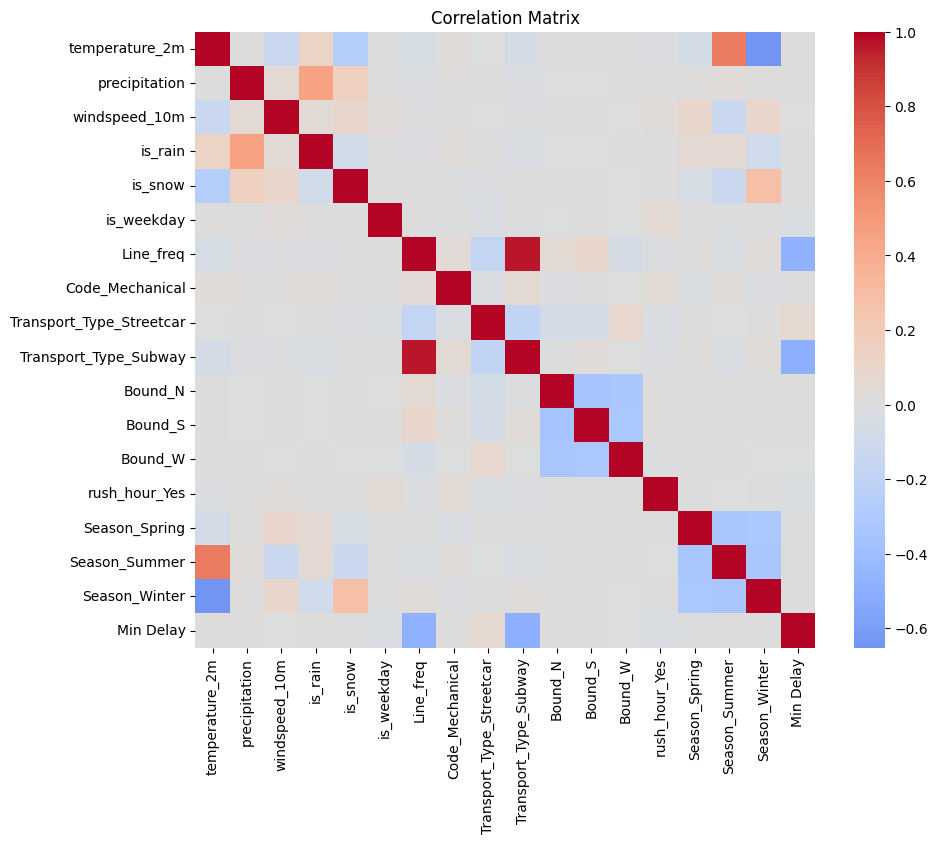

In [47]:
# Compute correlation matrix
# Calculate pairwise correlation between all numerical variables
# Values range from -1 to 1:
#  1   → strong positive correlation
#  0   → no correlation
# -1   → strong negative correlation
corr_matrix = df_corr.corr()


# Visualize correlation matrix
# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create heatmap to visualize correlations
# cmap="coolwarm" → blue (negative), red (positive)
# center=0 → ensures neutral color (white) at zero correlation
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

# Add title to the plot
plt.title("Correlation Matrix")

# Display the plot
plt.show()

In [48]:
X.shape,y.shape

((132052, 17), (132052,))

In [49]:
# Import required libraries
from sklearn.model_selection import train_test_split   # for splitting dataset
from sklearn.ensemble import RandomForestRegressor     # ML model (ensemble method)
from sklearn.metrics import mean_absolute_error, r2_score  # evaluation metrics



# Split dataset into training and testing sets
# - 70% training data
# - 30% testing data
# random_state ensures reproducibility (same split every time)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

### Train Random Forest model

In [50]:
# Initialize Random Forest Regressor
# random_state ensures consistent results
model = RandomForestRegressor(random_state=42)

# Train the model using training data
model.fit(X_train, y_train)

# Predict target values (Min Delay) for test dataset
pred = model.predict(X_test)


# Evaluate model performance

# Mean Absolute Error (MAE):
# Measures average difference between actual and predicted values
# Lower MAE → better performance
print("MAE:", mean_absolute_error(y_test, pred))

# R-squared (R2 Score):
# Measures how well the model explains variance in the data
# Ranges from 0 to 1 (higher is better)
print("R2:", r2_score(y_test, pred))

MAE: 5.148513838086055
R2: 0.31878881967690587


### Compute feature importance

In [51]:
# Create a pandas Series to store feature importance scores
# model.feature_importances_ --> importance values from Random Forest
# index=X.columns → assign feature names to importance scores
# sort_values(ascending=False) --> sort features from most to least important
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


# Print the importance of each feature
# Helps identify which variables have the greatest impact on predictions
print(feature_importance)

Transport_Type_Subway       0.249144
temperature_2m              0.211036
windspeed_10m               0.200476
Line_freq                   0.159859
precipitation               0.029886
is_weekday                  0.019544
Season_Spring               0.017858
Bound_W                     0.016887
Bound_S                     0.015822
Bound_N                     0.015727
rush_hour_Yes               0.014761
Season_Summer               0.011837
Season_Winter               0.009691
Code_Mechanical             0.008789
is_rain                     0.007271
Transport_Type_Streetcar    0.006881
is_snow                     0.004532
dtype: float64


### A binary variable called severe_delay was created to convert the delay prediction task into a classification problem. Delays greater than or equal to 15 minutes were labeled as severe (1), while delays below 15 minutes were labeled as non-severe (0).

In [52]:
# Generate descriptive statistics for Min Delay
ttc_weather["Min Delay"].describe()

count    132052.000000
mean         10.388294
std           9.715454
min           0.000000
25%           3.000000
50%           9.000000
75%          15.000000
max          60.000000
Name: Min Delay, dtype: float64

In [53]:
 # Count how many times each unique value of 'Min Delay' occurs
ttc_weather["Min Delay"].value_counts()

Min Delay
0     26443
10    18875
8      7721
3      6778
20     6747
      ...  
56       69
49       69
58       67
52       65
59       47
Name: count, Length: 61, dtype: int64

## Create target variable for classification
### Create a binary target variable 'severe_delay'
### If 'Min Delay' ≥ 15 minutes → 1 (severe delay)
### If 'Min Delay' < 15 minutes → 0 (non-severe delay)


In [54]:
ttc_weather["severe_delay"] = (ttc_weather["Min Delay"] >= 15).astype(int) #.astype(int) converts True/False into 1/0
ttc_weather.shape

(132052, 32)

In [55]:
# drop "Min Delay"
ttc_weather = ttc_weather.drop(columns=["Min Delay"])

In [56]:
# Define features (X) and target variable (y) for classification

# Create feature matrix X by dropping:
# - columns listed in drop_cols (irrelevant/redundant features) and "severe_delay" (target variable)
# This ensures X contains only input features used for prediction
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define target variable y
y = ttc_weather["severe_delay"]

In [57]:
# Combine X and y
df_corr = pd.concat([X, y], axis=1) # This allows analysis of relationships between predictors and the target (severe_delay)
df_corr.head() # Display first few rows to verify correct merging of features and target

,temperature_2m,precipitation,windspeed_10m,is_rain,is_snow,is_weekday,Line_freq,Code_Mechanical,Transport_Type_Streetcar,Transport_Type_Subway,Bound_N,Bound_S,Bound_W,rush_hour_Yes,Season_Spring,Season_Summer,Season_Winter,severe_delay
0,2.3,0.0,7.6,0,0,0,0.181986,True,False,True,False,True,False,False,False,False,True,0
1,2.3,0.0,7.6,0,0,0,0.147832,True,False,True,False,False,False,False,False,False,True,0
2,2.3,0.0,7.6,0,0,0,0.147832,False,False,True,False,False,True,False,False,False,True,0
3,2.4,0.0,10.5,0,0,0,0.181986,True,False,True,False,True,False,True,False,False,True,0
4,2.4,0.0,10.5,0,0,0,0.147832,True,False,True,False,False,False,True,False,False,True,0


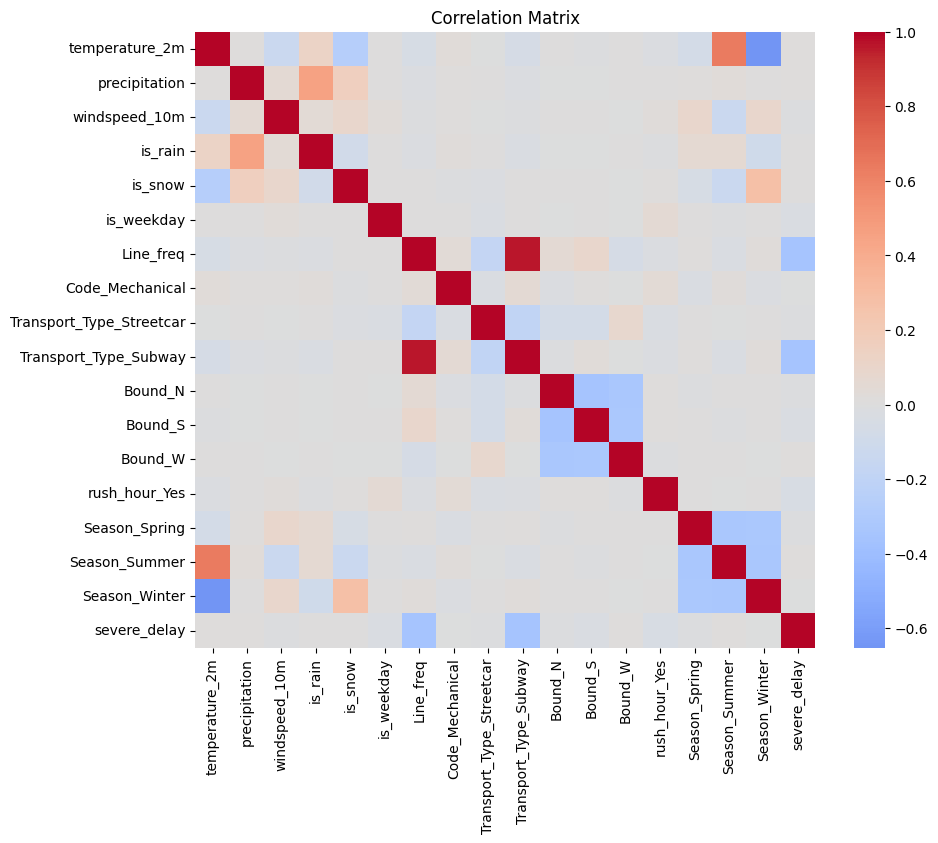

In [58]:
# Compute correlation matrix
corr_matrix = df_corr.corr()

plt.figure(figsize=(10,8))

# Create heatmap to visualize correlations
# cmap="coolwarm" → red (positive), blue (negative)
# center=0 → white color represents no correlation
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

plt.title("Correlation Matrix") # Add title to the plot

plt.show() # Display the heatmap

In [59]:
X.shape,y.shape

((132052, 17), (132052,))

In [60]:
# Count the proportion of each class in the target variable 'y'
# normalize=True converts counts into proportions (percentages)
print(y.value_counts(normalize=True))

severe_delay
0    0.740845
1    0.259155
Name: proportion, dtype: float64


In [61]:
from sklearn.model_selection import train_test_split   # for splitting dataset
from sklearn.ensemble import RandomForestClassifier    # classification model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  # evaluation metrics

# Split dataset into training and testing sets
# - 70% training data
# - 30% testing data
# random_state ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# **Random Forest Classifier Model1 with Class Weight Balancing**
### Random Forest Classifier with **class_weight='balanced'** to address class imbalance. This approach assigns a **higher penalty to errors made on the minority class**, improving the model's sensitivity to severe delays without altering the original dataset through resampling.

In [62]:
# Create Random Forest Classifier model
# class_weight="balanced" adjusts weights automatically to handle class imbalance
# (gives more importance to minority class → severe_delay)
clf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"   # important if imbalance exists
)



# Train the model
# Fit the model using training data
clf.fit(X_train, y_train)



# Make predictions
# Predict class labels (0 or 1) on the test dataset
# 0 → non-severe delay
# 1 → severe delay
pred = clf.predict(X_test)

In [63]:
# Evaluate classification model performance
# Print confusion matrix shows:
# - True Positives (TP)
# - True Negatives (TN)
# - False Positives (FP)
# - False Negatives (FN)

print("--- Random Forest Classifier Model1 with Class Weight Balancing ---")

print(confusion_matrix(y_test, pred))



# Detailed classification report Displays key evaluation metrics:
# - Precision → accuracy of positive predictions
# - Recall → ability to detect actual positives (important for severe delays)
# - F1-score → balance between precision and recall
# - Support → number of samples per class
print(classification_report(y_test, pred))


# Compute ROC-AUC score
# Get predicted probabilities for the positive class (class = 1 → severe_delay)
proba = clf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC score
# Measures how well the model distinguishes between classes
# Value ranges:
# - 0.5 → no better than random
# - 1.0 → perfect model
print("ROC AUC:", roc_auc_score(y_test, proba))

--- Random Forest Classifier Model1 with Class Weight Balancing ---
[[26575  2756]
 [ 5670  4615]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.86     29331
           1       0.63      0.45      0.52     10285

    accuracy                           0.79     39616
   macro avg       0.73      0.68      0.69     39616
weighted avg       0.77      0.79      0.77     39616

ROC AUC: 0.8120344747668835


In [64]:
# Compute feature importance
# clf.feature_importances_ → importance values from Random Forest Classifier
# index=X.columns → assign feature names to corresponding importance scores
# sort_values(ascending=False) → sort features from most to least important
importance = pd.Series(
    clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)


# Print the importance of each feature
# Helps identify which variables most influence prediction of severe delays
print(importance)

Line_freq                   0.325669
temperature_2m              0.221928
windspeed_10m               0.216397
Transport_Type_Subway       0.104919
precipitation               0.028991
Code_Mechanical             0.013013
is_weekday                  0.011309
Season_Spring               0.010981
Bound_W                     0.009881
rush_hour_Yes               0.008488
Season_Summer               0.008120
Season_Winter               0.008020
Bound_N                     0.007711
Transport_Type_Streetcar    0.007468
Bound_S                     0.006806
is_rain                     0.006779
is_snow                     0.003521
dtype: float64


# **Random Forest Classifier Model2 with Resampling (Over 0.4, Under 0.9)**

In [65]:
# ----------------------------
# Define features (X) and target variable (y)
# ----------------------------

# Create feature matrix X by dropping unnecessary columns and target
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define binary target variable
# 1 → severe delay, 0 → non-severe delay
y = ttc_weather["severe_delay"]


# ----------------------------
# Import required libraries
# ----------------------------

from sklearn.ensemble import RandomForestClassifier        # Random Forest classifier
from imblearn.over_sampling import RandomOverSampler       # oversampling minority class
from imblearn.under_sampling import RandomUnderSampler     # undersampling majority class
from imblearn.pipeline import Pipeline                     # pipeline to combine steps
from sklearn.metrics import classification_report, confusion_matrix  # evaluation metrics


# ----------------------------
# Define resampling strategy
# ----------------------------

# Oversampling:
# Increase minority class to 40% of majority class
over = RandomOverSampler(
    sampling_strategy=0.4,
    random_state=42
)

# Undersampling:
# Reduce majority class slightly (keeps more original data than aggressive undersampling)
# sampling_strategy=0.9 → majority ≈ 1.1x minority
under = RandomUnderSampler(
    sampling_strategy=0.9,
    random_state=42
)


# ----------------------------
# Build Random Forest pipeline
# ----------------------------

# Pipeline ensures:
# - Resampling happens only on training data (prevents data leakage)
# - Clean and reproducible workflow
rf_pipeline = Pipeline(steps=[
    ('o', over),   # oversample minority class
    ('u', under),  # undersample majority class
    ('model', RandomForestClassifier(
        n_estimators=100,   # number of trees
        random_state=42,    # reproducibility
        n_jobs=-1           # use all CPU cores for faster training
    ))
])


# ----------------------------
# Train and predict
# ----------------------------

# Fit the pipeline on training data
rf_pipeline.fit(X_train, y_train)

# Predict class labels on test set
y_pred_rf = rf_pipeline.predict(X_test)


# ----------------------------
# Evaluate model performance
# ----------------------------

print("--- Random Forest Classifier  Model2 with Resampling (Over 0.4, Under 0.9) ---")

# Confusion matrix:
# Displays TP, TN, FP, FN → helps analyze errors
print(confusion_matrix(y_test, y_pred_rf))

# Classification report:
# Focus on:
# - Recall (important for severe_delay detection)
# - F1-score (balance between precision and recall)
print(classification_report(y_test, y_pred_rf))

--- Random Forest Classifier  Model2 with Resampling (Over 0.4, Under 0.9) ---
[[21999  7332]
 [ 2832  7453]]
              precision    recall  f1-score   support

           0       0.89      0.75      0.81     29331
           1       0.50      0.72      0.59     10285

    accuracy                           0.74     39616
   macro avg       0.70      0.74      0.70     39616
weighted avg       0.79      0.74      0.76     39616



# **Balanced Random Forest Classifier with sampling_strategy=0.7**


#### A Balanced Random Forest classifier was implemented to **address class imbalance by resampling the minority class** during training  **sampling strategy of 0.7** was used, meaning the **minority class** was **increased to 70% of the majority class** size The model was evaluated using a confusion matrix and classification report, with emphasis on recall and F1-score for severe delay detection.

In [66]:
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])
y = ttc_weather["severe_delay"]

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Assuming X and y are your features and imbalanced target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# BalancedRandomForestClassifier:
# - Handles class imbalance by resampling minority class internally
# n_estimators=100 → number of trees in the forest
# sampling_strategy=0.7 → minority class is resampled to 70% of majority class
# random_state ensures consistent results
brf = BalancedRandomForestClassifier(
    n_estimators=100,
    sampling_strategy=0.7,
    random_state=42
)


# Fit the model
brf.fit(X_train, y_train)

# Make predictions
y_pred = brf.predict(X_test)

print("---Balanced Random Forest Classifier with sampling_strategy=0.7 ---")

# Confusion matrix:
# Shows TP, TN, FP, FN → helps analyze errors
print(confusion_matrix(y_test, y_pred))

# Evaluate (focus on Recall and F1-score for imbalanced data)
print(classification_report(y_test, y_pred))


---Balanced Random Forest Classifier with sampling_strategy=0.7 ---
[[21572  7759]
 [ 2619  7666]]
              precision    recall  f1-score   support

           0       0.89      0.74      0.81     29331
           1       0.50      0.75      0.60     10285

    accuracy                           0.74     39616
   macro avg       0.69      0.74      0.70     39616
weighted avg       0.79      0.74      0.75     39616



# **XGBoost classifier Model1 with Resampling (Over 0.4, Under 0.9).**
### under=0.9 keeps classes closer, less aggressive undersampling
### An XGBoost classifier was implemented using a resampling pipeline that combined oversampling and undersampling techniques to address class imbalance. The pipeline ensured that resampling was applied only to the training data, preventing data leakage. Model performance was evaluated using a confusion matrix and classification metrics.

In [74]:
# ----------------------------
# Define features (X) and target variable (y)
# ----------------------------

# Create feature matrix X by dropping unnecessary columns and target
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define binary target variable
# 1 → severe delay, 0 → non-severe delay
y = ttc_weather["severe_delay"]


# ----------------------------
# Import required libraries
# ----------------------------

from xgboost import XGBClassifier                          # powerful gradient boosting model
from imblearn.over_sampling import RandomOverSampler       # oversampling minority class
from imblearn.under_sampling import RandomUnderSampler     # undersampling majority class
from imblearn.pipeline import Pipeline                     # pipeline for combining steps
from sklearn.model_selection import train_test_split       # data splitting
from sklearn.metrics import classification_report          # evaluation metrics


# ----------------------------
# Define resampling strategy
# ----------------------------

# Oversampling:
# Increase minority class size using real data duplication (no synthetic data)
# sampling_strategy=0.4 → minority class becomes 40% of majority class
over = RandomOverSampler(
    sampling_strategy=0.4,
    random_state=42
)

# Undersampling:
# Reduce majority class size
# sampling_strategy=0.9 → majority becomes ~1.1x of minority (more balanced)
under = RandomUnderSampler(
    sampling_strategy=0.9,
    random_state=42
)


# ----------------------------
# Build pipeline
# ----------------------------

# Create pipeline to:
# 1. Oversample minority class
# 2. Undersample majority class
# 3. Train XGBoost model
# IMPORTANT: Resampling happens ONLY on training data → prevents data leakage
steps = [
    ('oversample', over),
    ('undersample', under),
    ('model', XGBClassifier(
        use_label_encoder=False,  # avoids deprecated warning
        eval_metric='logloss'     # evaluation metric for binary classification
    ))
]

pipeline = Pipeline(steps=steps)


# ----------------------------
# Split dataset
# ----------------------------

# Split data into train/test sets
# stratify=y ensures class distribution is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# ----------------------------
# Train the model
# ----------------------------

# Fit the entire pipeline (resampling + model training)
pipeline.fit(X_train, y_train)


# ----------------------------
# Make predictions and evaluate
# ----------------------------

# Predict class labels on test set
y_pred = pipeline.predict(X_test)

print("--- XGBoost classifier Model1 with Resampling (Over 0.4, Under 0.9) ---")

# Confusion matrix:
# Shows TP, TN, FP, FN → helps analyze model errors
print(confusion_matrix(y_test, y_pred))

# Classification report:
# Focus on:
# - Recall (important for severe_delay detection)
# - F1-score (balance between precision and recall)
print(classification_report(y_test, y_pred))

--- XGBoost classifier Model1 with Resampling (Over 0.4, Under 0.9) ---
[[24016  5333]
 [ 2203  8064]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.86     29349
           1       0.60      0.79      0.68     10267

    accuracy                           0.81     39616
   macro avg       0.76      0.80      0.77     39616
weighted avg       0.83      0.81      0.82     39616



In [75]:
# ----------------------------
# Generate predictions for FULL dataset (for Power BI)
# ----------------------------

# Predict class (0 = non-severe, 1 = severe)
ttc_weather["predicted_severe_delay"] = pipeline.predict(X)

# Predict probability of severe delay
ttc_weather["severe_delay_prob"] = pipeline.predict_proba(X)[:, 1]

In [76]:
# ttc_weather.to_csv("ttc_predictions.csv", index=False)

#**XGBoost Classifier Model2 with Resampling (Over 0.4, Under 0.5)**
### under = 0.5 reduces majority class more aggressively

In [70]:
# ----------------------------
# Define features (X) and target variable (y)
# ----------------------------

# Create feature matrix X by dropping unnecessary columns and target
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define binary target variable
# 1 → severe delay, 0 → non-severe delay
y = ttc_weather["severe_delay"]


# ----------------------------
# Import required libraries
# ----------------------------

from xgboost import XGBClassifier                          # powerful gradient boosting model
from imblearn.over_sampling import RandomOverSampler       # oversampling minority class
from imblearn.under_sampling import RandomUnderSampler     # undersampling majority class
from imblearn.pipeline import Pipeline                     # pipeline to combine steps
from sklearn.model_selection import train_test_split       # splitting dataset
from sklearn.metrics import classification_report          # evaluation metrics


# ----------------------------
# Define resampling strategy
# ----------------------------

# Oversampling:
# Increase minority class size using duplication of existing data
# sampling_strategy=0.4 → minority class becomes 40% of majority class
over = RandomOverSampler(
    sampling_strategy=0.4,
    random_state=42
)

# Undersampling:
# Reduce majority class size
# sampling_strategy=0.5 → majority class becomes ~2x the minority class
# (stronger balancing than previous setup)
under = RandomUnderSampler(
    sampling_strategy=0.5,
    random_state=42
)


# ----------------------------
# Build pipeline
# ----------------------------

# Pipeline ensures:
# - Resampling is applied ONLY to training data
# - Prevents data leakage
# - Keeps workflow clean and reproducible
steps = [
    ('oversample', over),   # increase minority class
    ('undersample', under), # reduce majority class
    ('model', XGBClassifier(
        use_label_encoder=False,  # avoids deprecated warning
        eval_metric='logloss'     # evaluation metric for binary classification
    ))
]

pipeline = Pipeline(steps=steps)


# ----------------------------
# Split dataset
# ----------------------------

# Split into training (70%) and testing (30%)
# stratify=y ensures class distribution is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


# ----------------------------
# Train the model
# ----------------------------

# Fit the pipeline (resampling + model training)
pipeline.fit(X_train, y_train)


# ----------------------------
# Make predictions and evaluate
# ----------------------------

# Predict class labels on test set
y_pred = pipeline.predict(X_test)

print("--- XGBoost Classifier Model2 with Resampling (Over 0.4, Under 0.5) ---")

# Confusion matrix:
# Shows True/False Positives and Negatives → helps analyze errors
print(confusion_matrix(y_test, y_pred))

# Classification report:
# Focus on:
# - Recall (important for detecting severe delays)
# - F1-score (balance between precision and recall)
print(classification_report(y_test, y_pred))

--- XGBoost Classifier Model2 with Resampling (Over 0.4, Under 0.5) ---
[[26314  3035]
 [ 3398  6869]]
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     29349
           1       0.69      0.67      0.68     10267

    accuracy                           0.84     39616
   macro avg       0.79      0.78      0.79     39616
weighted avg       0.84      0.84      0.84     39616



#**Logistic Regression Model1 with ReSampling (Over 0.4, Under 0.9)**
### A Logistic Regression model was implemented using a pipeline that included feature scaling and resampling techniques. Scaling was applied to normalize feature values, while oversampling and undersampling addressed class imbalance.

In [71]:
# ----------------------------
# Define features (X) and target variable (y)
# ----------------------------

# Create feature matrix X by dropping unnecessary columns and target
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define binary target variable
# 1 → severe delay, 0 → non-severe delay
y = ttc_weather["severe_delay"]


# ----------------------------
# Import required libraries
# ----------------------------

from sklearn.linear_model import LogisticRegression        # baseline classification model
from sklearn.preprocessing import StandardScaler           # feature scaling
from imblearn.over_sampling import RandomOverSampler       # oversampling minority class
from imblearn.under_sampling import RandomUnderSampler     # undersampling majority class
from imblearn.pipeline import Pipeline                     # pipeline to combine steps
from sklearn.metrics import classification_report, confusion_matrix  # evaluation metrics


# ----------------------------
# Define resampling strategy
# ----------------------------

# Oversampling:
# Increase minority class to 40% of majority class
over = RandomOverSampler(
    sampling_strategy=0.4,
    random_state=42
)

# Undersampling:
# Reduce majority class slightly (keeps more data)
# sampling_strategy=0.9 → majority ≈ 1.1x minority
under = RandomUnderSampler(
    sampling_strategy=0.9,
    random_state=42
)


# ----------------------------
# Build Logistic Regression pipeline
# ----------------------------

# Pipeline includes:
# 1. Scaling (important for Logistic Regression)
# 2. Oversampling
# 3. Undersampling
# 4. Model training
# NOTE: Scaling is applied before resampling to standardize feature ranges
lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),  # normalize features (important for LR)
    ('o', over),                   # oversample minority class
    ('u', under),                  # undersample majority class
    ('model', LogisticRegression(
        max_iter=1000,             # increase iterations to ensure convergence
        random_state=42
    ))
])


# ----------------------------
# Train and predict
# ----------------------------

# Fit pipeline on training data
lr_pipeline.fit(X_train, y_train)

# Predict class labels on test set
y_pred_lr = lr_pipeline.predict(X_test)


# ----------------------------
# Evaluate model performance
# ----------------------------

print("--- Logistic Regression Results with ReSampling (Over 0.4, Under 0.9) ---")

# Confusion matrix:
# Shows TP, TN, FP, FN → helps analyze prediction errors
print(confusion_matrix(y_test, y_pred_lr))

# Classification report:
# Focus on:
# - Recall (important for detecting severe delays)
# - F1-score (balance between precision and recall)
print(classification_report(y_test, y_pred_lr))

--- Logistic Regression Results with ReSampling (Over 0.4, Under 0.9) ---
[[14946 14403]
 [ 1160  9107]]
              precision    recall  f1-score   support

           0       0.93      0.51      0.66     29349
           1       0.39      0.89      0.54     10267

    accuracy                           0.61     39616
   macro avg       0.66      0.70      0.60     39616
weighted avg       0.79      0.61      0.63     39616



# **Logistic Regression Model2: class_weight='balanced', threshold = 0.5**
### A Logistic Regression model was implemented using a pipeline that included feature scaling. Class imbalance was handled using balanced class weights, eliminating the need for resampling. The pipeline ensured that scaling was applied consistently without data leakage.

In [72]:
# ----------------------------
# Define features (X) and target variable (y)
# ----------------------------

# Create feature matrix X by dropping unnecessary columns and target
X = ttc_weather.drop(columns=drop_cols + ["severe_delay"])

# Define binary target variable
# 1 → severe delay, 0 → non-severe delay
y = ttc_weather["severe_delay"]


# ----------------------------
# Import required libraries
# ----------------------------

from sklearn.pipeline import Pipeline              # pipeline for chaining steps
from sklearn.preprocessing import StandardScaler   # feature scaling
from sklearn.linear_model import LogisticRegression  # classification model
from sklearn.model_selection import train_test_split # data splitting
from sklearn.metrics import classification_report    # evaluation metrics


# ----------------------------
# Setup the pipeline
# ----------------------------

# Pipeline ensures:
# 1. StandardScaler is fitted ONLY on training data
# 2. Same scaling is applied to test data → prevents data leakage
# 3. Model training happens after scaling

pipeline = Pipeline([
    ('scaler', StandardScaler()),  # normalize feature values (important for LR)

    # Logistic Regression model:
    # class_weight='balanced' adjusts weights automatically for imbalanced data
    ('logreg', LogisticRegression(class_weight='balanced'))
])


# ----------------------------
# Split dataset
# ----------------------------

# Split data into:
# - 70% training
# - 30% testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)


# ----------------------------
# Train the model
# ----------------------------

# Fit the entire pipeline:
# - scaler learns from X_train
# - transformed data is passed to Logistic Regression
pipeline.fit(X_train, y_train)


# ----------------------------
# Make predictions
# ----------------------------

# Predict class labels on test set
# Pipeline automatically:
# - scales X_test using training parameters
# - applies the trained model
y_pred = pipeline.predict(X_test)


# ----------------------------
# Evaluate model performance
# ----------------------------

print("--- Logistic Regression Model 2: class_weight='balanced', threshold = 0.5 ---")

# Print confusion matrix:
print(confusion_matrix(y_test, y_pred))

# Print classification metrics:
# - Precision → correctness of predictions
# - Recall → ability to detect severe delays (very important)
# - F1-score → balance between precision and recall
print(classification_report(y_test, y_pred))

--- Logistic Regression Model 2: class_weight='balanced', threshold = 0.5 ---
[[14885 14446]
 [ 1166  9119]]
              precision    recall  f1-score   support

           0       0.93      0.51      0.66     29331
           1       0.39      0.89      0.54     10285

    accuracy                           0.61     39616
   macro avg       0.66      0.70      0.60     39616
weighted avg       0.79      0.61      0.63     39616



# **Logistic Regression Model 2: class_weight='balanced', threshold = 0.3**
### A custom classification threshold  was applied to predicted probabilities to improve recall for severe delays. Lowering the threshold increased sensitivity, allowing the model to capture more critical delay events.

In [73]:
# ----------------------------
# Get predicted probabilities
# ----------------------------

# Obtain predicted probabilities for the positive class (class = 1 → severe_delay)
# predict_proba returns probabilities for both classes → [:, 1] selects class 1
y_probs = pipeline.predict_proba(X_test)[:, 1]


# ----------------------------
# Apply custom classification threshold
# ----------------------------

# Define a custom threshold (instead of default 0.5)
# Lower threshold (0.3) → more sensitive → increases recall (captures more severe delays)
custom_threshold = 0.3

# Convert probabilities into class predictions using custom threshold
# If probability ≥ threshold → classify as 1 (severe delay)
# Else → 0 (non-severe delay)
y_pred_custom = (y_probs >= custom_threshold).astype(int)


# ----------------------------
# Evaluate model with custom threshold
# ----------------------------

# Generate classification report comparing actual labels vs custom predictions
# Helps analyze impact of threshold tuning on precision, recall, and F1-score
report = classification_report(y_test, y_pred_custom)


# ----------------------------
# Display results
# ----------------------------
print("--- Logistic Regression Model 2: class_weight='balanced', threshold = 0.3 ---")

# Print confusion matrix:
print(confusion_matrix(y_test, y_pred_custom))

# Print classification report for chosen threshold
print("Classification Report for Threshold 0.3:")
print(report)


--- Logistic Regression Model 2: class_weight='balanced', threshold = 0.3 ---
[[13126 16205]
 [  683  9602]]
Classification Report for Threshold 0.3:
              precision    recall  f1-score   support

           0       0.95      0.45      0.61     29331
           1       0.37      0.93      0.53     10285

    accuracy                           0.57     39616
   macro avg       0.66      0.69      0.57     39616
weighted avg       0.80      0.57      0.59     39616

